<a href="https://www.kaggle.com/code/sonawanelalitsunil/netflix-life-impact-dataset-nlid-ml-100?scriptVersionId=235433831" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflix-life-impact-dataset-nlid/Netflix Life Impact Dataset (NLID).csv


## Title: Netflix Life Impact Dataset (NLID)

#### Description: A dataset capturing how Netflix content influences viewers' emotions, behavior, and lifestyle choices, offering insights into media impact on daily life.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/netflix-life-impact-dataset-nlid/Netflix Life Impact Dataset (NLID).csv')

In [3]:
df.head()

,Movie Title,Genre,Release Year,Average Rating,Number of Reviews,Review Highlights,Minute of Life-Changing Insight,How Discovered,Meaningful Advice Taken,Suggested to Friends/Family (Y/N %)
0,The Pursuit of Happyness,Drama,2006,9.1,42000,"""Will Smith’s struggle hit hard. A must-watch!...",78:15 – Chris gets the job,Friend suggested,Persistence pays off.,92% Y
1,The Social Dilemma,Documentary,2020,8.2,35000,"""Eye-opening about tech addiction."" / ""Some cl...",12:40 – Algorithm manipulation,Social media,Limit screen time for mental health.,88% Y
2,Parasite,Thriller/Drama,2019,9.3,50000,"""Masterpiece on class inequality."" / ""Too dark...",1:12:00 – The flood scene,Netflix recommendation,Privilege isn’t always visible.,85% Y
3,Paddington 2,Comedy/Family,2017,8.8,28000,"""Pure joy! Teaches kindness effortlessly."" / ""...",33:10 – Paddington’s jail speech,Friend suggested,Always choose kindness.,95% Y
4,Inception,Sci-Fi,2010,9.0,45000,"""Mind-bending brilliance."" / ""Confusing plot.""",1:05:22 – Cobb’s totem scene,Social media,Reality is subjective.,80% Y


In [4]:
df.tail()

,Movie Title,Genre,Release Year,Average Rating,Number of Reviews,Review Highlights,Minute of Life-Changing Insight,How Discovered,Meaningful Advice Taken,Suggested to Friends/Family (Y/N %)
77,The Last Days of American Crime,Action,2020,4.0,9000,"""Worst Netflix film?"" / ""Unwatchable.""",1:30:00 – Final heist,Netflix original,Crime doesn’t pay (literally).,20% Y
78,Klaus,Animation,2019,8.7,32000,"""Instant Christmas classic."" / ""Predictable.""",1:05:00 – Gift delivery montage,Netflix original,Kindness sparks miracles.,94% Y
79,Ma Rainey’s Black Bottom,Drama,2020,7.9,25000,"""Chadwick Boseman’s last role."" / ""Theatrical.""","1:20:00 – ""They Don’t Care"" monologue",Oscar buzz,Art demands sacrifice.,85% Y
80,Piece of Women,Drama,2021,8.3,27000,"""Devastating childbirth scene."" / ""Graphic.""",1:10:00 – Courtroom speech,Film festival,Grief changes everything.,76% Y
81,The Harder They Fall,Western,2021,7.6,18000,"""Stylish Black cowboy flick."" / ""Style over su...",1:20:00 – Final shootout,Netflix recommendation,Revenge is a loop.,73% Y


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Movie Title                          82 non-null     object 
 1   Genre                                82 non-null     object 
 2   Release Year                         82 non-null     int64  
 3   Average Rating                       82 non-null     float64
 4   Number of Reviews                    82 non-null     int64  
 5   Review Highlights                    82 non-null     object 
 6   Minute of Life-Changing Insight      82 non-null     object 
 7   How Discovered                       82 non-null     object 
 8   Meaningful Advice Taken              82 non-null     object 
 9   Suggested to Friends/Family (Y/N %)  82 non-null     object 
dtypes: float64(1), int64(2), object(7)
memory usage: 6.5+ KB


In [6]:
df.describe()

,Release Year,Average Rating,Number of Reviews
count,82.000000,82.000000,82.000000
mean,2018.304878,7.547561,23146.341463
std,2.365853,1.097160,12796.722141
min,2006.000000,4.000000,8000.000000
25%,2017.250000,6.925000,13000.000000
50%,2019.000000,7.800000,19000.000000
75%,2020.000000,8.300000,31000.000000
max,2021.000000,9.400000,65000.000000


In [7]:
df.isnull().sum()

Movie Title                            0
Genre                                  0
Release Year                           0
Average Rating                         0
Number of Reviews                      0
Review Highlights                      0
Minute of Life-Changing Insight        0
How Discovered                         0
Meaningful Advice Taken                0
Suggested to Friends/Family (Y/N %)    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Movie Title                             object
Genre                                   object
Release Year                             int64
Average Rating                         float64
Number of Reviews                        int64
Review Highlights                       object
Minute of Life-Changing Insight         object
How Discovered                          object
Meaningful Advice Taken                 object
Suggested to Friends/Family (Y/N %)     object
dtype: object

In [10]:
df.shape

(82, 10)

In [11]:
df.columns

Index(['Movie Title', 'Genre', 'Release Year', 'Average Rating',
       'Number of Reviews', 'Review Highlights',
       'Minute of Life-Changing Insight', 'How Discovered',
       'Meaningful Advice Taken', 'Suggested to Friends/Family (Y/N %)'],
      dtype='object')

## Data visualizations

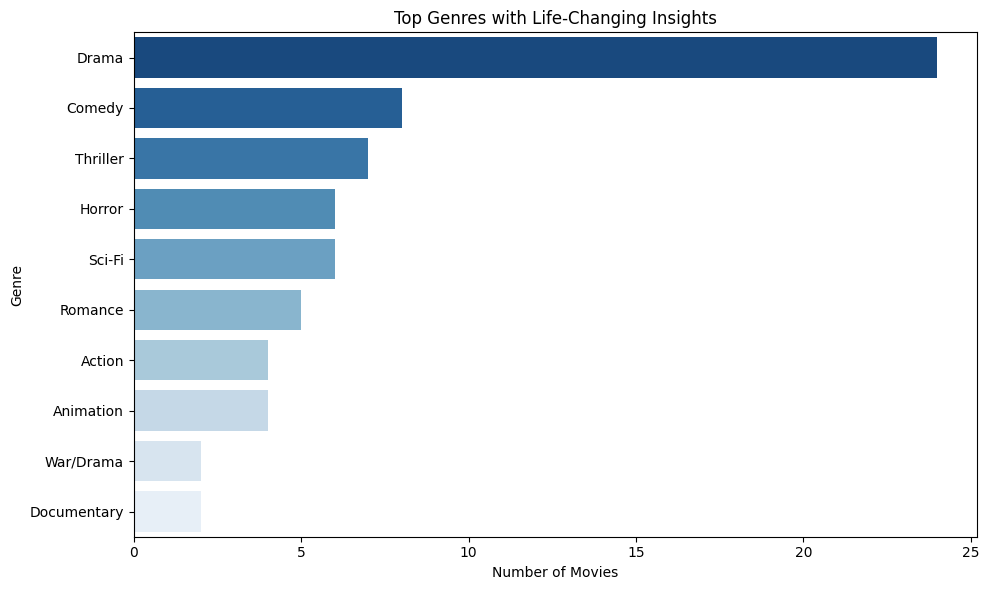

In [12]:
plt.figure(figsize=(10, 6))
genre_counts = df[df['Minute of Life-Changing Insight'].notnull()]['Genre'].value_counts().head(10)
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="Blues_r")
plt.title("Top Genres with Life-Changing Insights")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


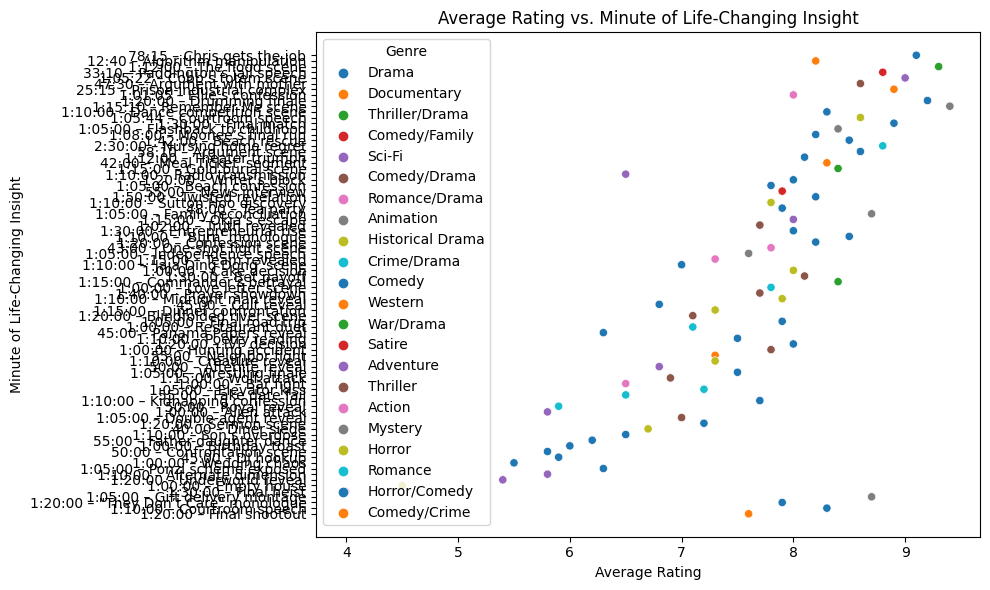

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Average Rating', y='Minute of Life-Changing Insight', hue='Genre', palette='tab10')
plt.title("Average Rating vs. Minute of Life-Changing Insight")
plt.xlabel("Average Rating")
plt.ylabel("Minute of Life-Changing Insight")
plt.tight_layout()
plt.show()


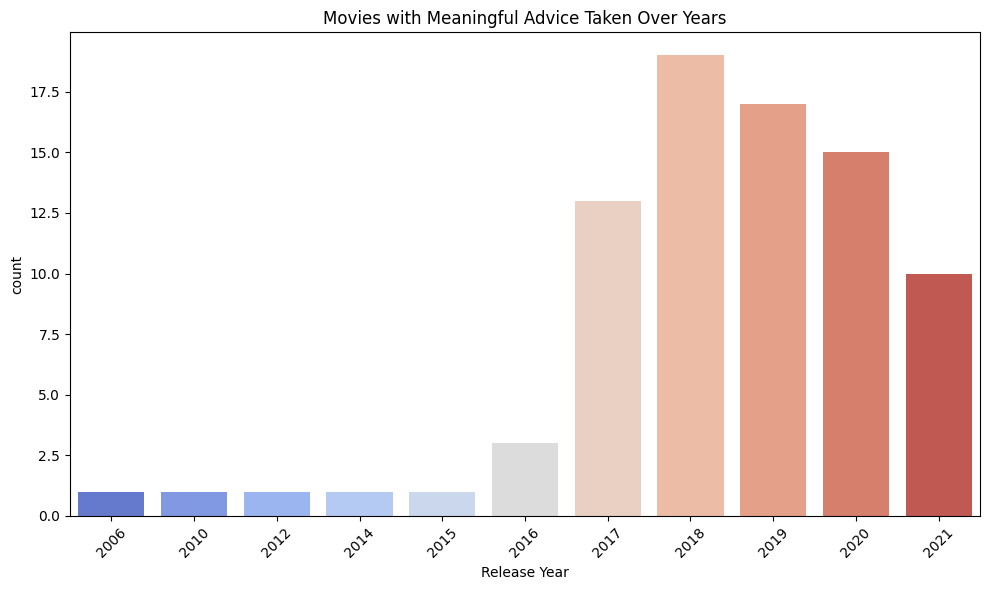

In [14]:
meaningful = df[df['Meaningful Advice Taken'].notnull()]
plt.figure(figsize=(10, 6))
sns.countplot(data=meaningful, x='Release Year', palette="coolwarm")
plt.title("Movies with Meaningful Advice Taken Over Years")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


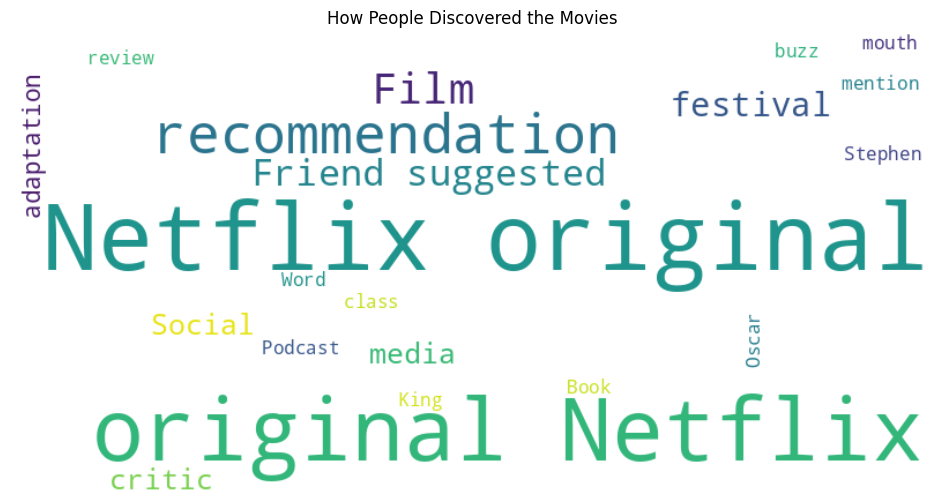

In [15]:
from wordcloud import WordCloud

text = " ".join(df['How Discovered'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("How People Discovered the Movies")
plt.show()


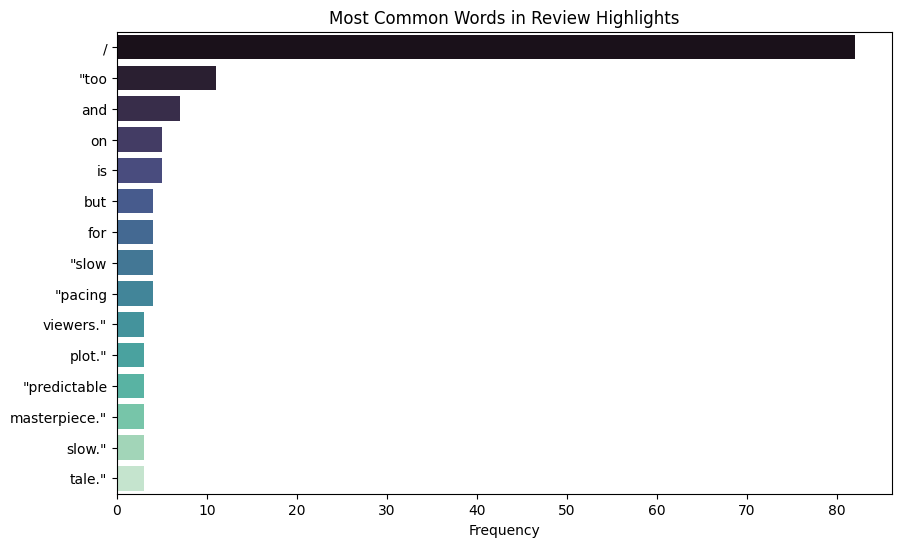

In [16]:
from collections import Counter
from itertools import chain

# Simple tokenizer
reviews = df['Review Highlights'].dropna().astype(str).str.lower().str.split()
common_words = Counter(chain.from_iterable(reviews)).most_common(15)

words, counts = zip(*common_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette="mako")
plt.title("Most Common Words in Review Highlights")
plt.xlabel("Frequency")
plt.show()


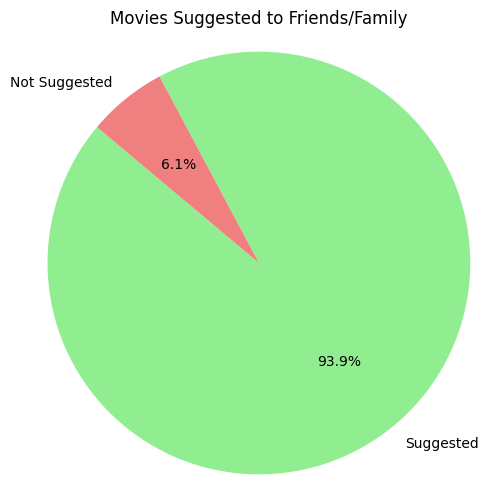

In [17]:
suggest_counts = df['Suggested to Friends/Family (Y/N %)'].dropna().astype(str).str.extract(r'(\d+)').astype(int)
suggested = suggest_counts[0].apply(lambda x: 'Suggested' if x > 50 else 'Not Suggested').value_counts()

plt.figure(figsize=(6, 6))
plt.pie(suggested, labels=suggested.index, autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'], startangle=140)
plt.title("Movies Suggested to Friends/Family")
plt.axis('equal')
plt.show()


In [18]:
# Extract minutes as integers from the format '78:15 – ...'
df['Insight Minute'] = df['Minute of Life-Changing Insight'].str.extract(r'(\d+):')[0].astype(int)


In [19]:
import plotly.express as px

fig = px.scatter(
    df,
    x='Number of Reviews',
    y='Average Rating',
    size='Insight Minute',  # Use the cleaned numeric column
    color='Genre',
    hover_name='Movie Title',
    title='Rating vs Reviews (Bubble Size = Insight Timing)'
)
fig.show()


## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [21]:
# 1. Preprocessing Target Variable (Suggested or Not)
df['Suggested_Label'] = df['Suggested to Friends/Family (Y/N %)'].str.extract(r'(\d+)').astype(int)
df['Suggested_Label'] = df['Suggested_Label'].apply(lambda x: 1 if x > 50 else 0)

In [22]:
# 2. Selecting Features and Target
features = df[['Genre', 'Release Year', 'Average Rating', 'Number of Reviews', 'How Discovered']]
target = df['Suggested_Label']

In [23]:
# 3. Encode categorical variables
le_genre = LabelEncoder()
le_discovered = LabelEncoder()
features['Genre'] = le_genre.fit_transform(features['Genre'])
features['How Discovered'] = le_discovered.fit_transform(features['How Discovered'])


In [24]:
# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=42)


In [25]:
# 5. Initialize ML models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

In [26]:
# 6. Train, Predict, Evaluate
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    results.append((name, acc * 100))  # store accuracy as percentage
    print(f"\n📌 {name}")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy: {acc * 100:.2f}%")



📌 Logistic Regression
Confusion Matrix:
[[ 0  1]
 [ 0 20]]
Accuracy: 95.24%

📌 Decision Tree
Confusion Matrix:
[[ 1  0]
 [ 0 20]]
Accuracy: 100.00%

📌 Random Forest
Confusion Matrix:
[[ 1  0]
 [ 0 20]]
Accuracy: 100.00%

📌 SVM
Confusion Matrix:
[[ 0  1]
 [ 0 20]]
Accuracy: 95.24%

📌 Naive Bayes
Confusion Matrix:
[[ 0  1]
 [ 0 20]]
Accuracy: 95.24%

📌 KNN
Confusion Matrix:
[[ 0  1]
 [ 0 20]]
Accuracy: 95.24%


In [27]:
# 7. Summary Table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy (%)"])
results_df = results_df.sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)
print("\n🔍 Model Accuracy Summary:")
print(results_df)


🔍 Model Accuracy Summary:
                 Model  Accuracy (%)
0        Decision Tree    100.000000
1        Random Forest    100.000000
2  Logistic Regression     95.238095
3                  SVM     95.238095
4          Naive Bayes     95.238095
5                  KNN     95.238095


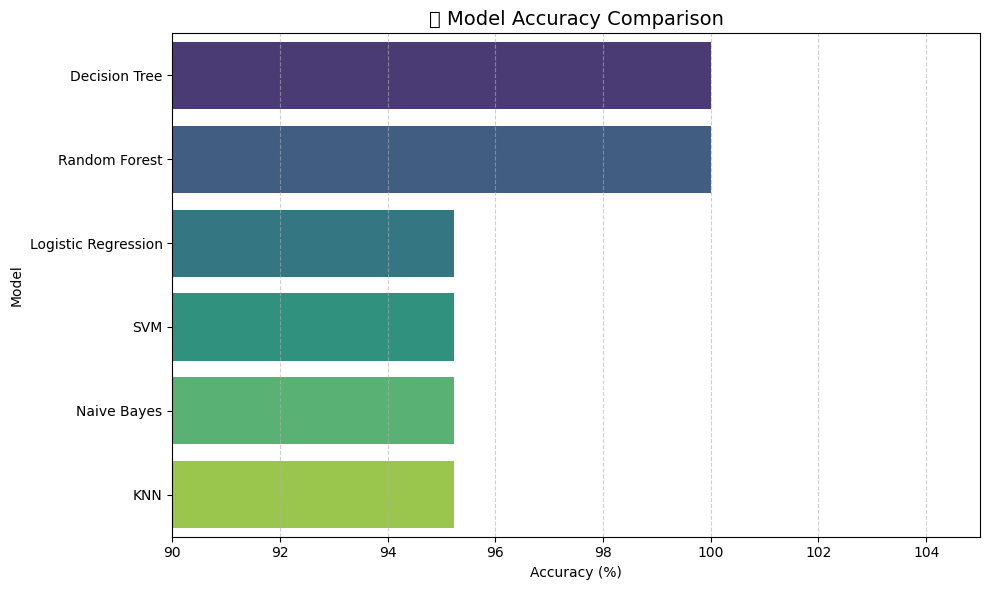

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy (%)', y='Model', data=results_df, palette='viridis')
plt.title('🔍 Model Accuracy Comparison', fontsize=14)
plt.xlabel('Accuracy (%)')
plt.ylabel('Model')
plt.xlim(90, 105)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Thank you..pls upvote!!!!